In [15]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.offline as py
import plotly.graph_objs as go
import plotly.tools as tls
from bs4 import BeautifulSoup
from sklearn.model_selection import cross_validate
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import learning_curve
from sklearn.ensemble import ExtraTreesClassifier

from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer , CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
py.init_notebook_mode(connected = True)

In [16]:
train = pd.read_csv('E:\Python Project\ML-projects-\mbti_1.csv')
us = pd.read_csv('Users.csv')
ps = pd.read_csv('E:\Python Project\ML-projects-\ForumMessages.csv')
train.head()
train.shape

C:\Users\Dilan\AppData\Local\Temp\ipykernel_22380\1338146608.py:3: DtypeWarning: Columns (0: MedalAwardDate) have mixed types. Specify dtype option on import or set low_memory=False.
  ps = pd.read_csv('E:\Python Project\ML-projects-\ForumMessages.csv')


(8675, 2)

In [17]:
mbti = {'I' : "Introversion" , 'E': "Extraversion" , 'N' : "Intuition" , 'S' : "Sensing" , 'F' : "Feeling" , 'T' : "Thinking" , 'J' : "Judging" , 'P' : "Perceiving"}

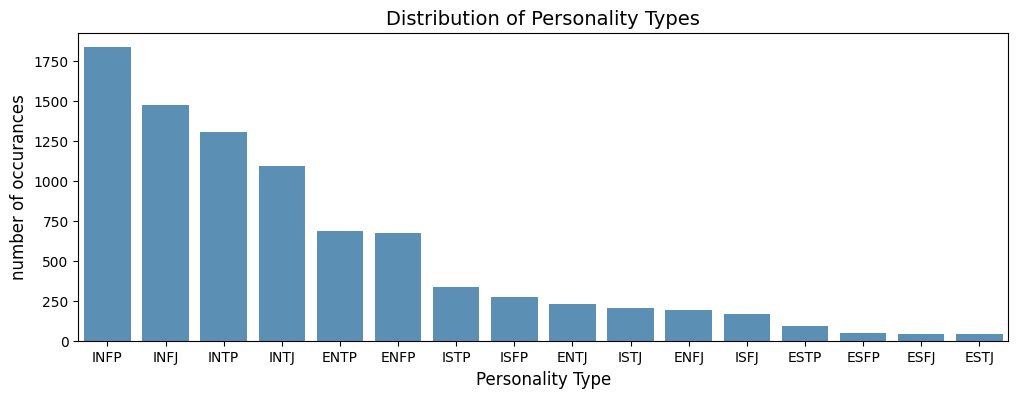

In [18]:
cnt_srs = train['type'].value_counts()
plt.figure(figsize = (12,4))
sns.barplot(x=cnt_srs.index, y=cnt_srs.values, alpha = 0.8)
plt.ylabel("number of occurances" , fontsize = 12)
plt.xlabel("Personality Type" , fontsize = 12)
plt.title("Distribution of Personality Types" , fontsize = 14)
plt.show()

In [19]:
ps['Message'] = ps['Message'].fillna('')


In [20]:
ps_join = ps.groupby('PostUserId')['Message'].agg(lambda col : ''.join(col)).reset_index()

In [21]:
etc = ExtraTreesClassifier(n_estimators = 20 , max_depth = 4 , n_jobs = -1)
tfidf = TfidfVectorizer(ngram_range =(1,1) , stop_words = 'english' )
tsvd = TruncatedSVD(n_components = 10)
model = Pipeline([('tfidf' , tfidf) , ('tsvd' , tsvd) , ('etc' , etc)])

In [22]:
kfolds = StratifiedKFold(n_splits = 5 , shuffle = True , random_state = 1)

In [23]:
np.random.seed(1)

scoring = {'acc':'accuracy' , 'neg_log_loss':'neg_log_loss' , 'f1_micro':'f1_micro'}
results = cross_validate(model , train['posts'] , train['type'] , cv = kfolds , scoring = scoring , n_jobs = -1)

In [24]:
print("cv accuracy :{:0.4f}(+/-{:0.4f}) ".format(np.mean(results['test_acc']), np.std(results['test_acc'])))
print("cv F1 :{:0.4f}(+/-{:0.4f}) ".format(np.mean(results['test_f1_micro']), np.std(results['test_f1_micro'])))
print("cv log loss :{:0.4f}(+/-{:0.4f}) ".format(np.mean(-results['test_neg_log_loss']), np.std(-results['test_neg_log_loss'])))

cv accuracy :0.2935(+/-0.0246) 
cv F1 :0.2935(+/-0.0246) 
cv log loss :2.1485(+/-0.0213) 


In [25]:
def cleanText(text):
    text = BeautifulSoup(text , 'lxml').get_text()
    text = re.sub(r'\|\|\|' , r'' , text)
    text = re.sub(r'http\S+' ,R'<URL>'  , text)
    return text
    

In [26]:
train['clean_posts' ] = train['posts'].apply(cleanText)



In [27]:
np.random.seed(1)
tfidf2 = CountVectorizer(ngram_range = (1,1) , 
                          stop_words = 'english',
                           lowercase = True,
                           max_features = 5000)

model_nb = Pipeline([('tfidf' , tfidf2) , ('nb' , MultinomialNB())])
results_nb = cross_validate(model_nb , train['clean_posts'] , train['type'] , cv = kfolds , scoring = scoring , n_jobs = -1)


In [29]:
print("cv accuracy :{:0.4f}(+/-{:0.4f}) ".format(np.mean(results['test_acc']), np.std(results['test_acc'])))
print("cv F1 :{:0.4f}(+/-{:0.4f}) ".format(np.mean(results['test_f1_micro']), np.std(results['test_f1_micro'])))
print("cv log loss :{:0.4f}(+/-{:0.4f}) ".format(np.mean(-results['test_neg_log_loss']), np.std(-results['test_neg_log_loss'])))

cv accuracy :0.2935(+/-0.0246) 
cv F1 :0.2935(+/-0.0246) 
cv log loss :2.1485(+/-0.0213) 


In [ ]:
train_sizes , train_scores , test_scores = learning_curve(model_lr , train['clean_posts'] , train['type'] , cv = kfolds , n_jobs = -1 , scoring = 'f1_micro' , train_sizes = np.linspace(.1 , 1.0 ,))

NameError: name 'model_lr' is not defined